In [1]:
!pip install utilsforecast statsforecast mlforecast neuralforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.2/263.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.7/280.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from google.colab import files

In [3]:
upload = files.upload()

Saving processedErzeugungMonthly to processedErzeugungMonthly


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, SeasonalNaive

from mlforecast import MLForecast
from mlforecast.target_transforms import LocalStandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, TFT

import warnings
warnings.filterwarnings('ignore')

In [5]:
erzeugung = pd.read_csv("processedErzeugungMonthly")

erzeugung.tail()

,Datum von,Datum bis,Gesamterzeugung [MWh],Biomasse [MWh],Wasserkraft [MWh],Wind Offshore [MWh],Wind Onshore [MWh],Photovoltaik [MWh],Sonstige Erneuerbare [MWh],Kernenergie [MWh],Braunkohle [MWh],Steinkohle [MWh],Erdgas [MWh],Pumpspeicher [MWh],Sonstige Konventionelle [MWh]
54,2025-06-01,2025-07-01,34502382.00,2819445.00,1343208.75,1848906.25,8676526.75,10536110.75,65539.75,0.0,3635517.75,1201003.75,2394517.25,916778.25,1064827.75
55,2025-07-01,2025-08-01,33616454.59,2882519.84,1405119.49,1561247.83,6167800.71,9056373.02,66518.95,0.0,5754061.25,1909475.25,2927114.00,808930.25,1077294.00
56,2025-08-01,2025-09-01,31975152.15,2852499.35,1463011.45,1699077.95,5459159.51,9672278.48,73973.16,0.0,4518747.75,1301445.00,3015974.75,843045.25,1075939.50
57,2025-09-01,2025-10-01,34608223.46,2806358.21,1208876.63,2410541.28,9707913.57,6546358.91,66353.11,0.0,4925688.75,1397569.00,3790773.75,733651.25,1014139.00
58,2025-10-01,2025-11-01,39873287.81,3012369.21,1101271.62,2899280.50,13715347.63,3838084.50,65807.22,0.0,5648721.13,2166156.53,5275413.52,756737.01,1394098.94


In [6]:
erzeugung['Datum von'] = pd.to_datetime(erzeugung['Datum von'])
erzeugung['Datum bis'] = pd.to_datetime(erzeugung['Datum bis'])

##Modelling with Production as Focus

Melting DFs and renaming to fit statsforecast, mlforecast, and neuralforecast better

In [7]:
erzeugung_melted = erzeugung.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')

erzeugung_melted.rename(columns={'Datum von': 'ds'}, inplace=True)

erzeugung_melted.head()

,ds,unique_id,y
0,2020-12-01,Gesamterzeugung [MWh],45983751.25
1,2021-01-01,Gesamterzeugung [MWh],47170005.50
2,2021-02-01,Gesamterzeugung [MWh],41770396.50
3,2021-03-01,Gesamterzeugung [MWh],45452515.00
4,2021-04-01,Gesamterzeugung [MWh],42260696.00


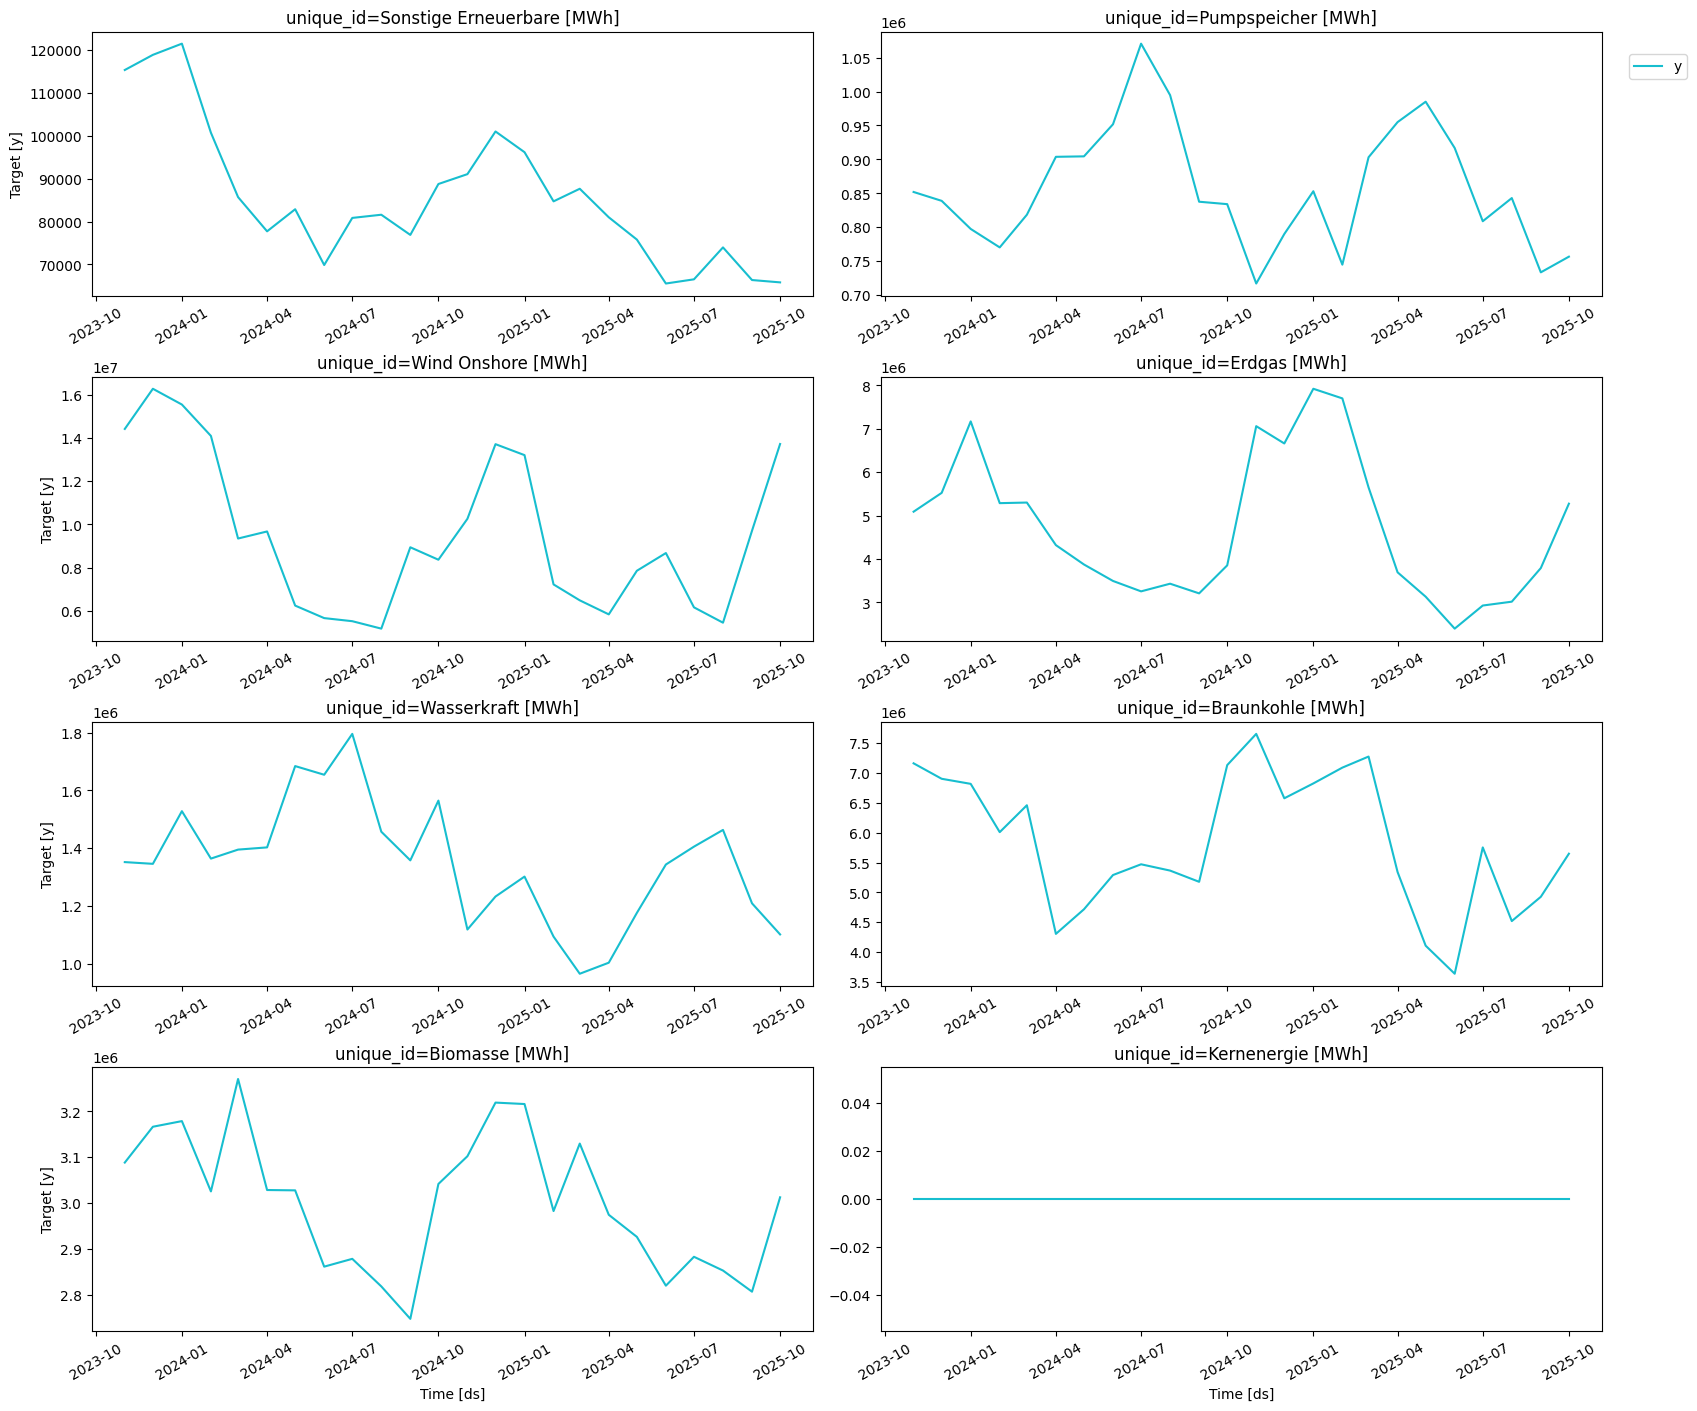

In [8]:
plot_series(df=erzeugung_melted, max_insample_length=24)

In [9]:
testErzeugungStat = erzeugung_melted.groupby('unique_id').tail(3)
trainErzeugungStat = erzeugung_melted.drop(testErzeugungStat.index)

###Statsforecast

In [10]:
models = [
    AutoARIMA(alias="ARIMA"),
    AutoARIMA(season_length=12, alias="SARIMA"),
    SeasonalNaive(season_length=12)
]

sf = StatsForecast(models=models, freq='MS')
sf.fit(trainErzeugungStat)
predStatErz = sf.predict(3)

predStatErz.head()

,unique_id,ds,ARIMA,SARIMA,SeasonalNaive
0,Biomasse [MWh],2025-08-01,2.851130e+06,2.781127e+06,2817887.25
1,Biomasse [MWh],2025-09-01,2.866751e+06,2.692517e+06,2747048.00
2,Biomasse [MWh],2025-10-01,2.858977e+06,2.986968e+06,3041499.25
3,Braunkohle [MWh],2025-08-01,5.754061e+06,5.471610e+06,5365300.25
4,Braunkohle [MWh],2025-09-01,5.754061e+06,5.462351e+06,5177279.75


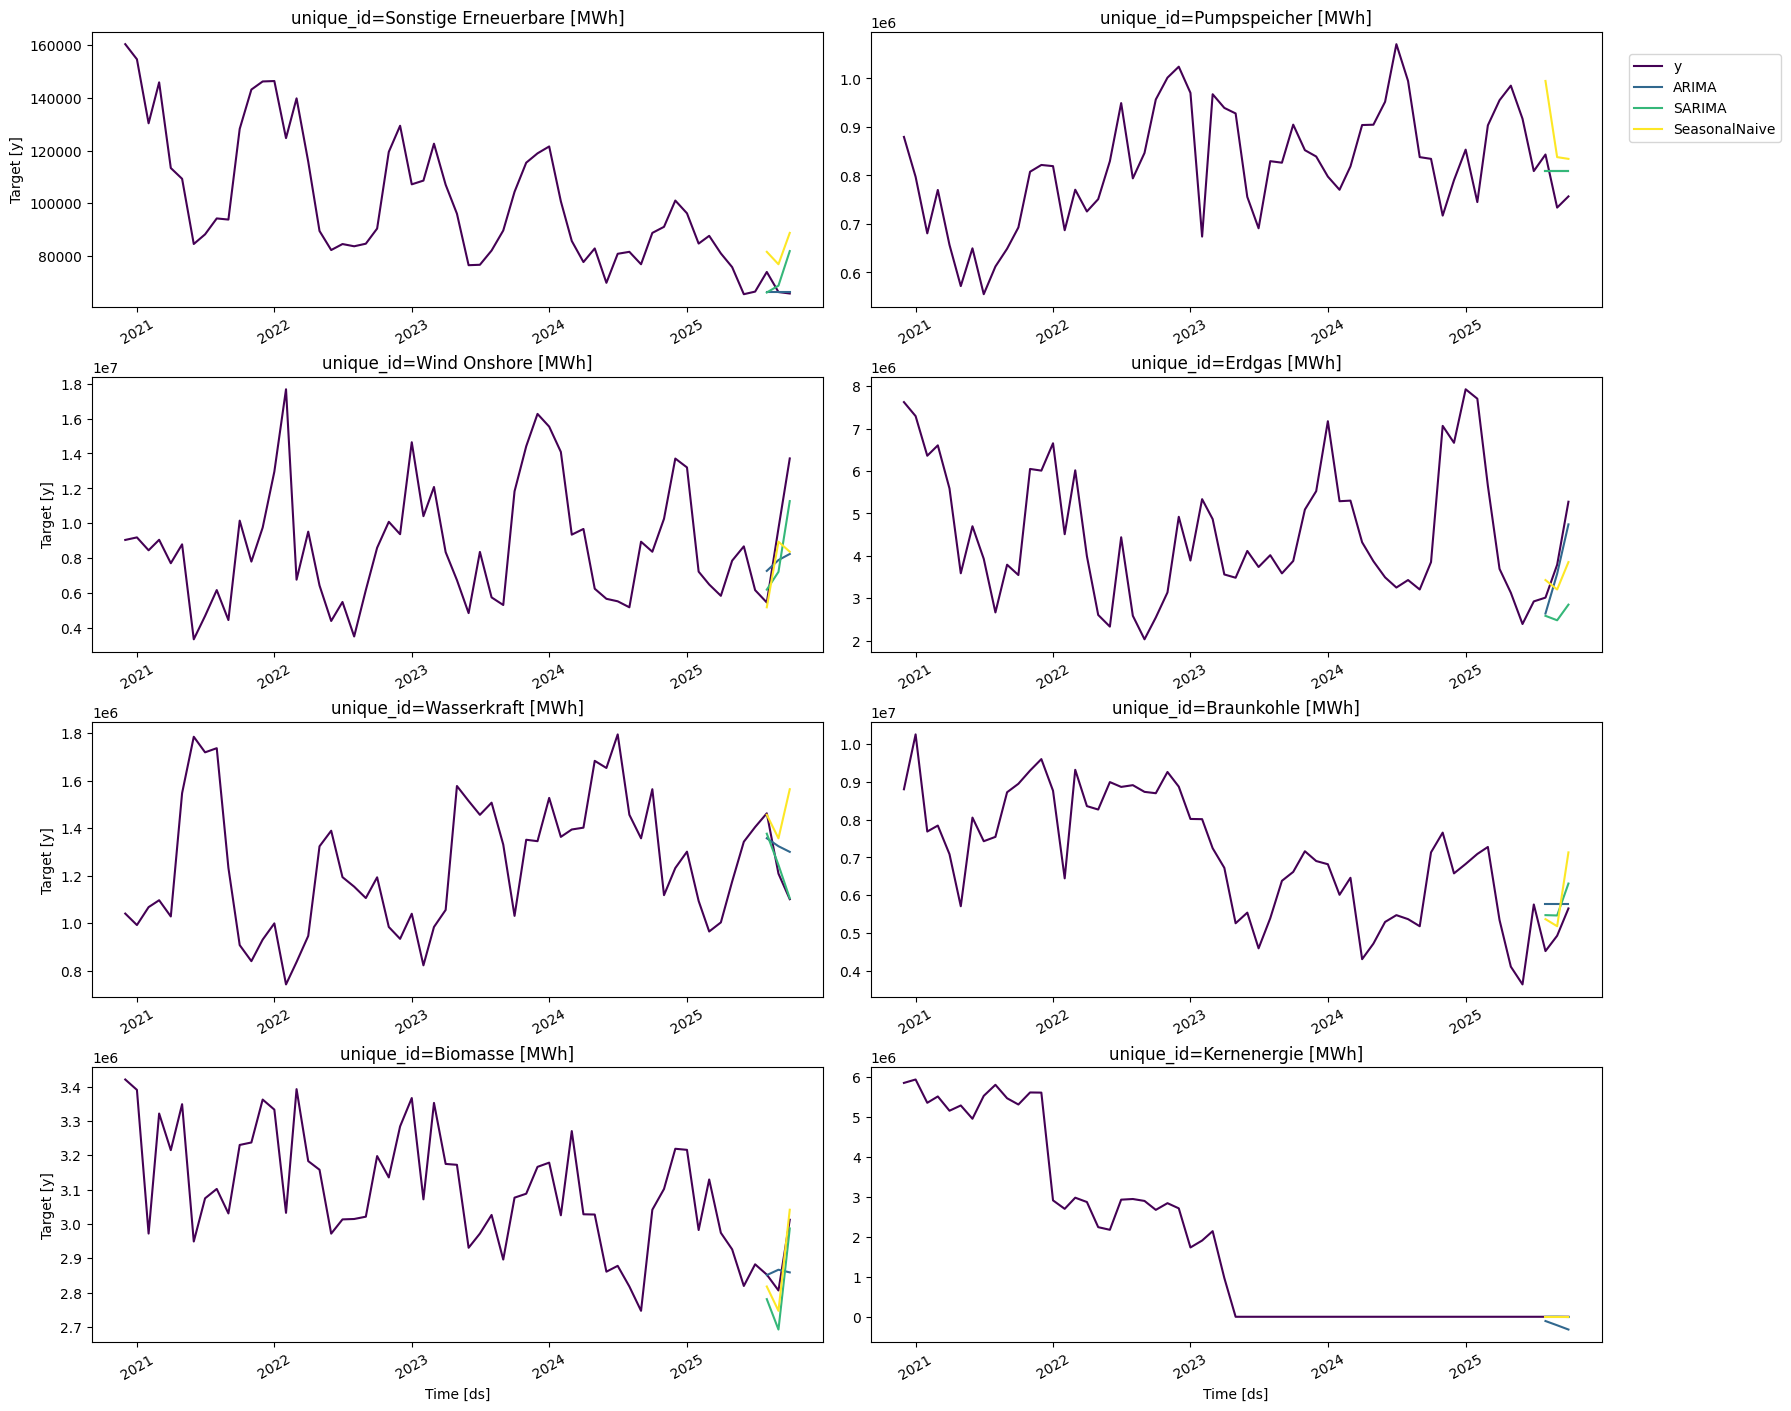

In [11]:
plot_series(df=erzeugung_melted, forecasts_df=predStatErz, palette="viridis")

In [12]:
eval_df = pd.merge(testErzeugungStat, predStatErz, "left", ["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,ARIMA,SARIMA,SeasonalNaive
0,Biomasse [MWh],mae,7.171827e+04,7.020488e+04,4.101745e+04
1,Braunkohle [MWh],mae,7.230087e+05,7.164073e+05,8.611449e+05
2,Erdgas [MWh],mae,3.734748e+05,1.387209e+06,8.067521e+05
3,Gesamterzeugung [MWh],mae,2.963302e+06,3.105701e+06,2.234647e+06
4,Kernenergie [MWh],mae,2.123649e+05,2.906302e+03,0.000000e+00


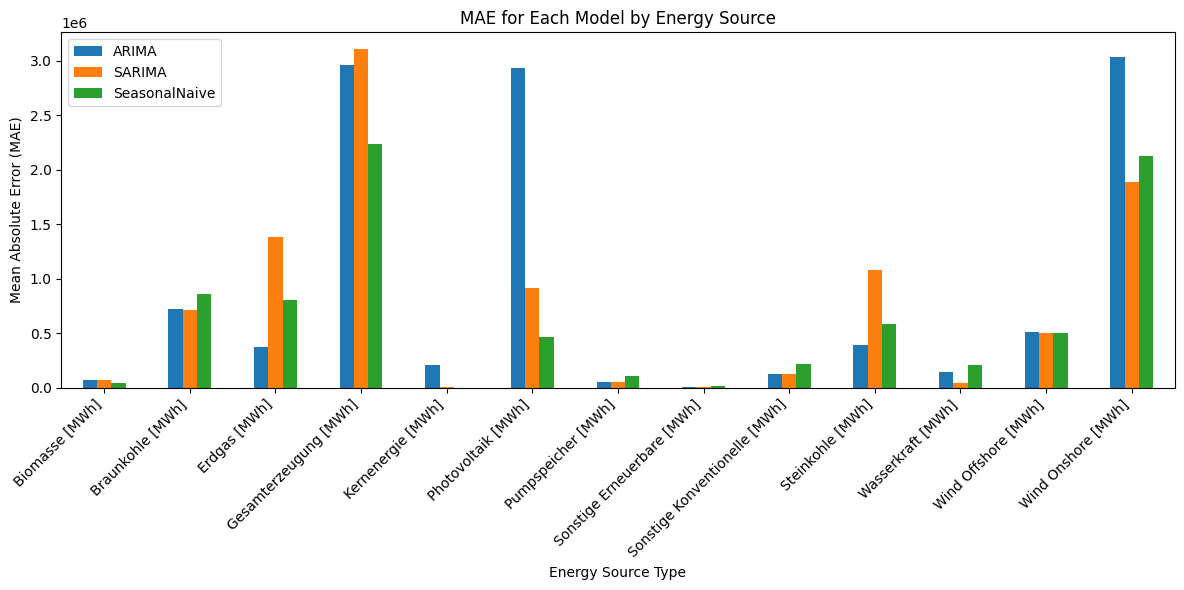

In [13]:
evaluation_for_plot = evaluation.set_index('unique_id')
evaluation_for_plot = evaluation_for_plot.drop(columns='metric')

evaluation_for_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cross-validation

In [14]:
models = [
    AutoARIMA(alias="ARIMA"),
    AutoARIMA(season_length=12, alias="SARIMA"),
    SeasonalNaive(season_length=12)
]

sf = StatsForecast(models=models, freq='MS')
cv = sf.cross_validation(
    df=trainErzeugungStat,
    h=3,
    step_size=3,
    n_windows=4,
    refit=True,
)

cv.head()

,unique_id,ds,cutoff,y,ARIMA,SARIMA,SeasonalNaive
0,Biomasse [MWh],2024-08-01,2024-07-01,2817887.25,2.868741e+06,2.931067e+06,3026313.25
1,Biomasse [MWh],2024-09-01,2024-07-01,2747048.00,2.873824e+06,2.801103e+06,2896349.50
2,Biomasse [MWh],2024-10-01,2024-07-01,3041499.25,2.871046e+06,2.981454e+06,3076700.75
3,Biomasse [MWh],2024-11-01,2024-10-01,3102041.50,2.877941e+06,2.981803e+06,3088185.75
4,Biomasse [MWh],2024-12-01,2024-10-01,3219102.00,2.968792e+06,3.060007e+06,3166389.25


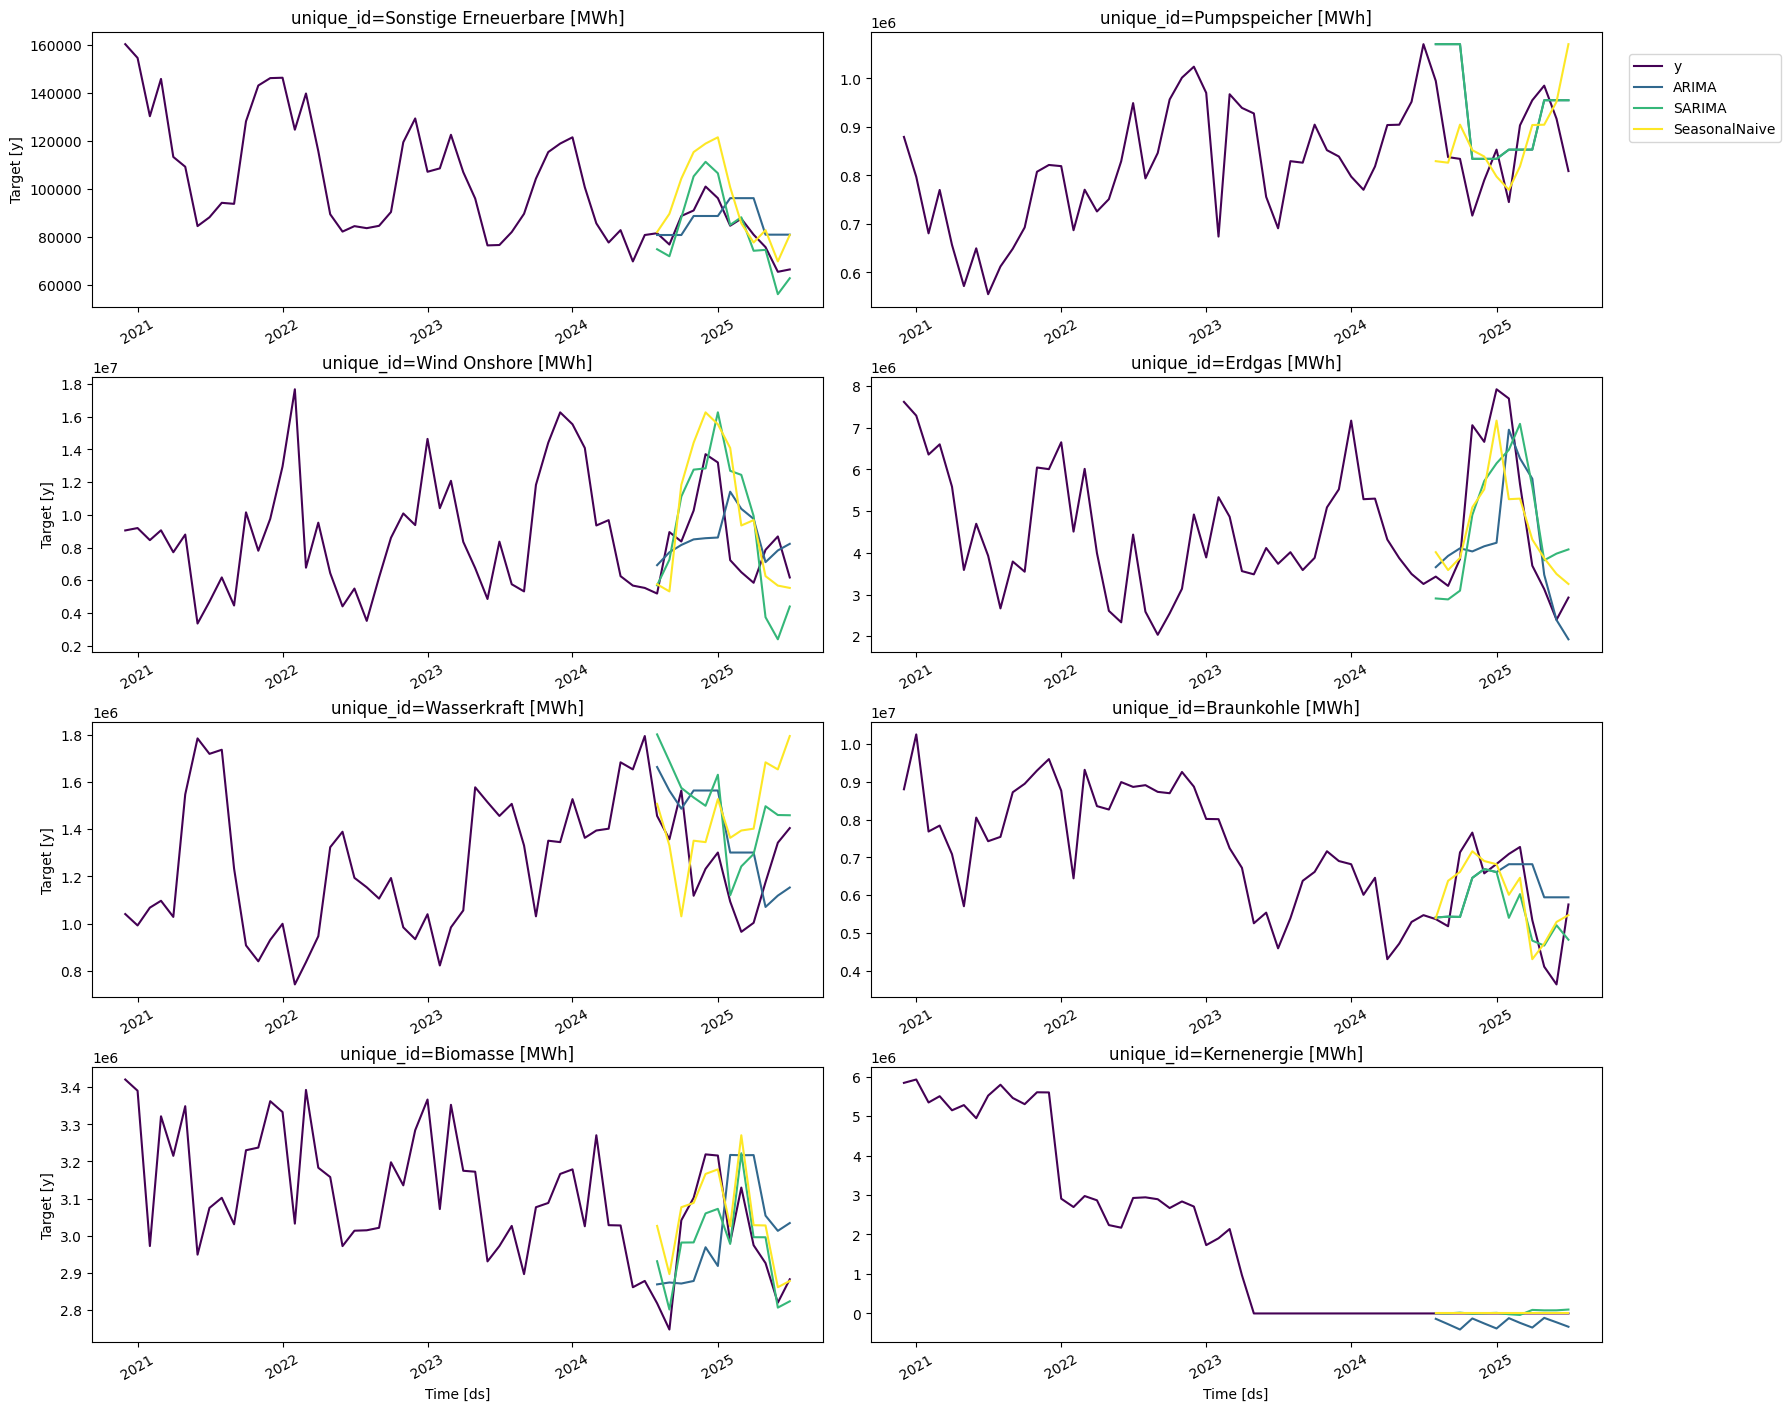

In [15]:
plot_series(df=trainErzeugungStat, forecasts_df=cv.drop(columns=["y", "cutoff"]), palette="viridis")

In [16]:
cv_eval = evaluate(cv.drop(columns="cutoff"), metrics=[mae])

cv_eval = cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
cv_eval

,metric,ARIMA,SARIMA,SeasonalNaive
0,mae,877702.517848,725072.512752,689476.696154


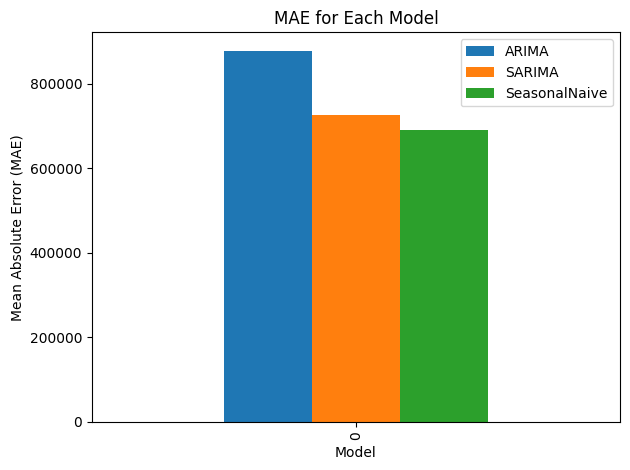

In [17]:
cv_eval.plot(kind="bar")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Model")
plt.title("MAE for Each Model")
plt.tight_layout()
plt.show()

###MLForecast

In [18]:
testErzeugung = erzeugung.tail(3)
trainErzeugung = erzeugung.drop(testErzeugung.index)

In [19]:
trainErzeugung = trainErzeugung.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')
testErzeugung = testErzeugung.drop(columns="Datum bis").melt(id_vars=['Datum von'], var_name='unique_id', value_name='y')

trainErzeugung.rename(columns={'Datum von': 'ds'}, inplace=True)
testErzeugung.rename(columns={'Datum von': 'ds'}, inplace=True)

display(trainErzeugung.tail())
display(testErzeugung.tail())

,ds,unique_id,y
723,2025-03-01,Sonstige Konventionelle [MWh],1223664.75
724,2025-04-01,Sonstige Konventionelle [MWh],1169981.00
725,2025-05-01,Sonstige Konventionelle [MWh],1182706.25
726,2025-06-01,Sonstige Konventionelle [MWh],1064827.75
727,2025-07-01,Sonstige Konventionelle [MWh],1077294.00


,ds,unique_id,y
34,2025-09-01,Pumpspeicher [MWh],733651.25
35,2025-10-01,Pumpspeicher [MWh],756737.01
36,2025-08-01,Sonstige Konventionelle [MWh],1075939.50
37,2025-09-01,Sonstige Konventionelle [MWh],1014139.00
38,2025-10-01,Sonstige Konventionelle [MWh],1394098.94


In [20]:
models = [
    LinearRegression(),
    XGBRegressor(),
    LGBMRegressor()
]

mlf = MLForecast(models=models, freq='MS', lags=list(range(1, 12)), target_transforms=[LocalStandardScaler()])

mlf.fit(trainErzeugung)
predMlErz = mlf.predict(3)

predMlErz.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000263 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2148
[LightGBM] [Info] Number of data points in the train set: 585, number of used features: 11
[LightGBM] [Info] Start training from score -0.040110
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,unique_id,ds,LinearRegression,XGBRegressor,LGBMRegressor
0,Biomasse [MWh],2025-08-01,2.897712e+06,2.981524e+06,2.991893e+06
1,Biomasse [MWh],2025-09-01,2.988035e+06,2.941006e+06,3.007209e+06
2,Biomasse [MWh],2025-10-01,3.037507e+06,3.009035e+06,3.121423e+06
3,Braunkohle [MWh],2025-08-01,5.635442e+06,5.593414e+06,5.925201e+06
4,Braunkohle [MWh],2025-09-01,6.198881e+06,6.464997e+06,6.467599e+06


In [21]:
eval_df = pd.merge(testErzeugung, predMlErz, "left", ["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,LinearRegression,XGBRegressor,LGBMRegressor
0,Biomasse [MWh],mae,8.400897e+04,8.900206e+04,1.497660e+05
1,Braunkohle [MWh],mae,1.141428e+06,1.396243e+06,1.467245e+06
2,Erdgas [MWh],mae,1.993844e+05,4.787980e+05,7.082702e+05
3,Gesamterzeugung [MWh],mae,2.000930e+06,2.476531e+06,1.138116e+06
4,Kernenergie [MWh],mae,4.256625e+05,3.567038e+05,2.192151e+05


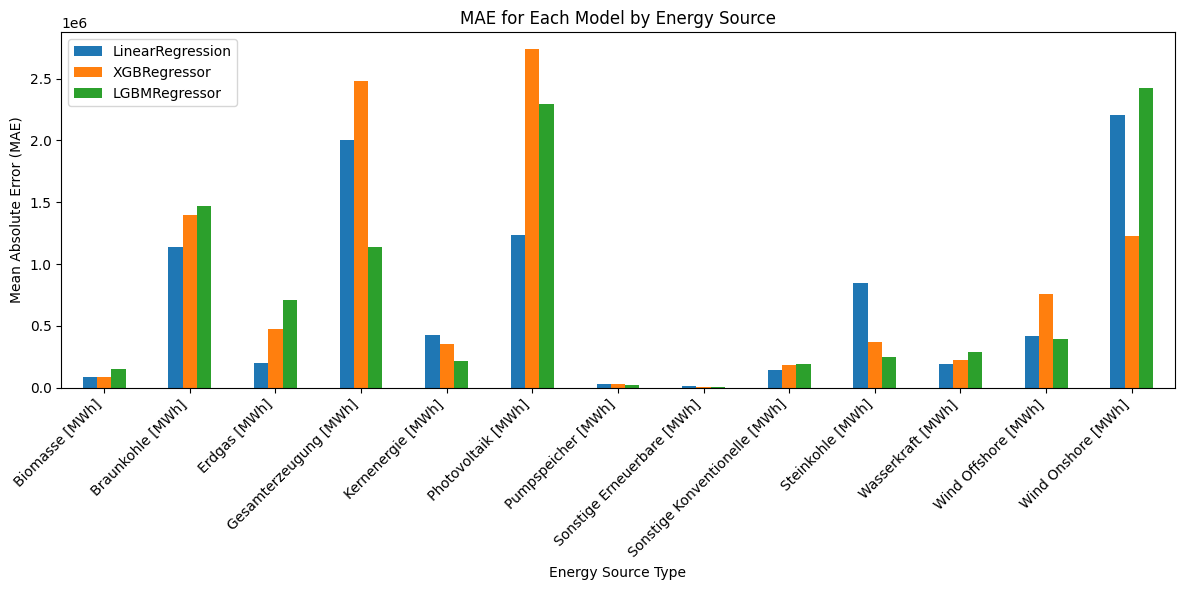

In [22]:
evaluation_to_plot = evaluation.drop(columns="metric").set_index("unique_id")

evaluation_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ML Cross-Validation

In [23]:
models = [
    LinearRegression(),
    XGBRegressor(),
    LGBMRegressor()
]

mlf = MLForecast(models=models, freq="MS", lags=list(range(1, 13)), target_transforms=[LocalStandardScaler()])

cv_ml = mlf.cross_validation(df=trainErzeugung, n_windows=4, h=3)

cv_ml

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1668
[LightGBM] [Info] Number of data points in the train set: 416, number of used features: 12
[LightGBM] [Info] Start training from score -0.051285
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,unique_id,ds,cutoff,y,LinearRegression,XGBRegressor,LGBMRegressor
0,Biomasse [MWh],2024-08-01,2024-07-01,2817887.25,2.896778e+06,2.955593e+06,2.941093e+06
1,Biomasse [MWh],2024-09-01,2024-07-01,2747048.00,2.952380e+06,2.905392e+06,2.909943e+06
2,Biomasse [MWh],2024-10-01,2024-07-01,3041499.25,2.987747e+06,3.024028e+06,2.992241e+06
3,Braunkohle [MWh],2024-08-01,2024-07-01,5365300.25,5.893620e+06,5.749221e+06,5.426982e+06
4,Braunkohle [MWh],2024-09-01,2024-07-01,5177279.75,6.398938e+06,6.267514e+06,5.627830e+06
...,...,...,...,...,...,...,...
151,Wind Offshore [MWh],2025-06-01,2025-04-01,1848906.25,1.196742e+06,1.042768e+06,1.245493e+06
152,Wind Offshore [MWh],2025-07-01,2025-04-01,1561247.83,1.313588e+06,9.769825e+05,1.189312e+06
153,Wind Onshore [MWh],2025-05-01,2025-04-01,7858113.25,5.050740e+06,5.942089e+06,5.283075e+06
154,Wind Onshore [MWh],2025-06-01,2025-04-01,8676526.75,4.901176e+06,5.449103e+06,5.191364e+06


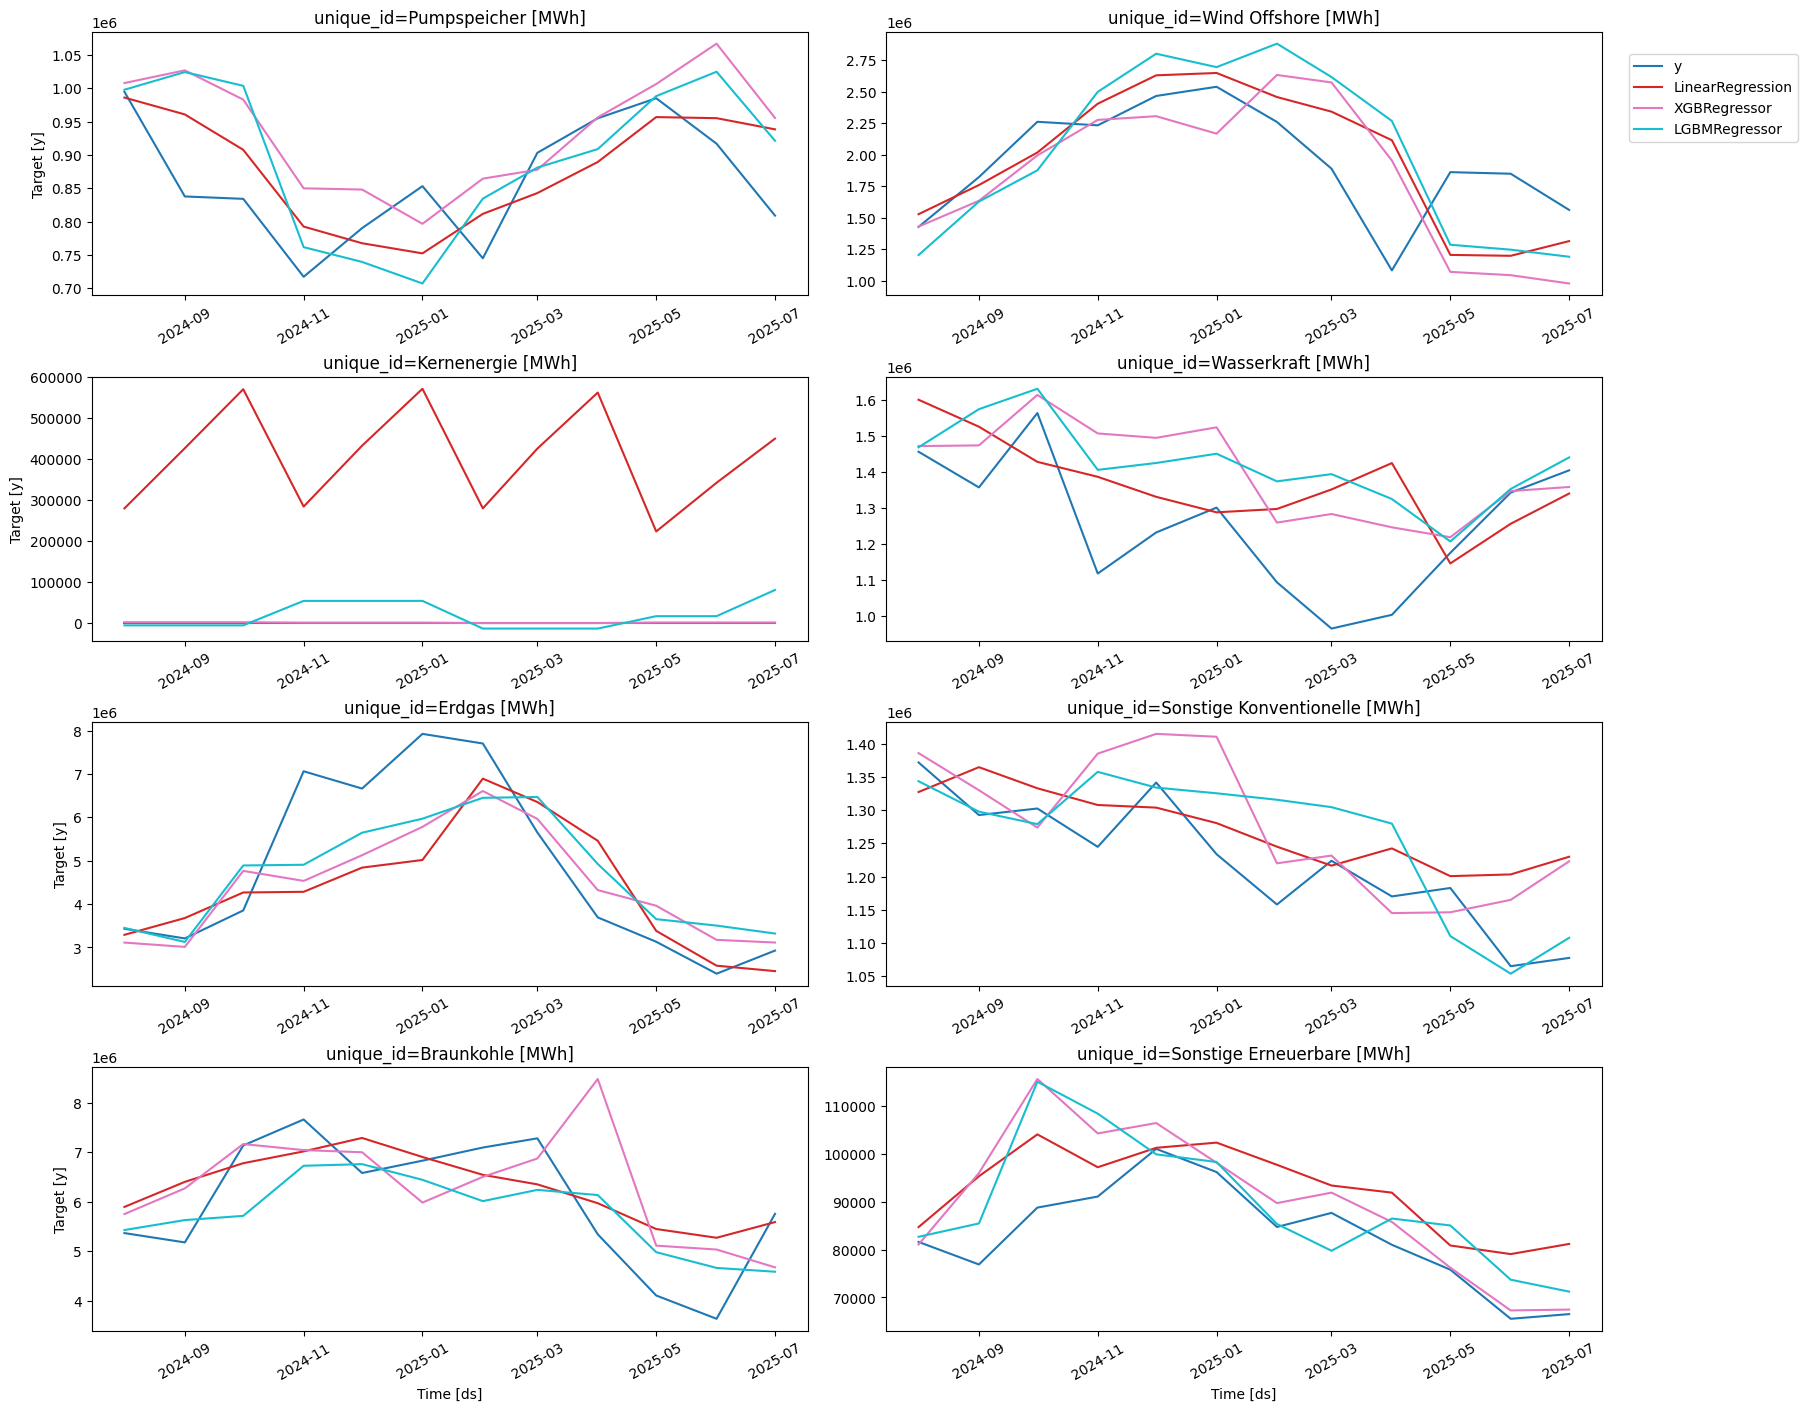

In [24]:
plot_series(forecasts_df=cv_ml.drop(columns='cutoff'))

In [25]:
mlf_cv_eval = evaluate(cv_ml.drop(columns="cutoff"), metrics=[mae])

mlf_cv_eval = mlf_cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
mlf_cv_eval

,metric,LinearRegression,XGBRegressor,LGBMRegressor
0,mae,709483.354188,828643.992113,712263.78369


<Axes: >

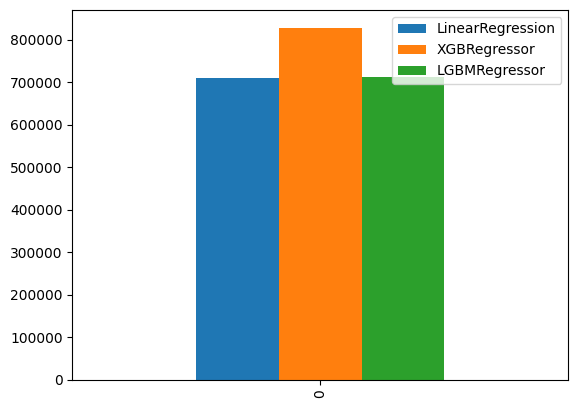

In [26]:
mlf_cv_eval.plot(kind="bar")

In [27]:
mlf_cv_eval = evaluate(cv_ml.drop(columns="cutoff"), metrics=[mae])
mlf_to_plot = mlf_cv_eval.drop(columns="metric").set_index("unique_id")
mlf_to_plot

,LinearRegression,XGBRegressor,LGBMRegressor
unique_id,,,
Biomasse [MWh],9.473322e+04,1.128948e+05,1.290605e+05
Braunkohle [MWh],7.320591e+05,9.168682e+05,7.846433e+05
Erdgas [MWh],1.060239e+06,9.559514e+05,9.661771e+05
Gesamterzeugung [MWh],2.244289e+06,2.946184e+06,2.054985e+06
Kernenergie [MWh],4.036534e+05,1.417330e+03,2.776630e+04
Photovoltaik [MWh],1.214617e+06,1.636674e+06,1.418371e+06
Pumpspeicher [MWh],6.603638e+04,8.849560e+04,8.177627e+04
Sonstige Erneuerbare [MWh],9.348060e+03,7.013354e+03,7.718781e+03
Sonstige Konventionelle [MWh],6.420223e+04,7.069206e+04,6.099774e+04


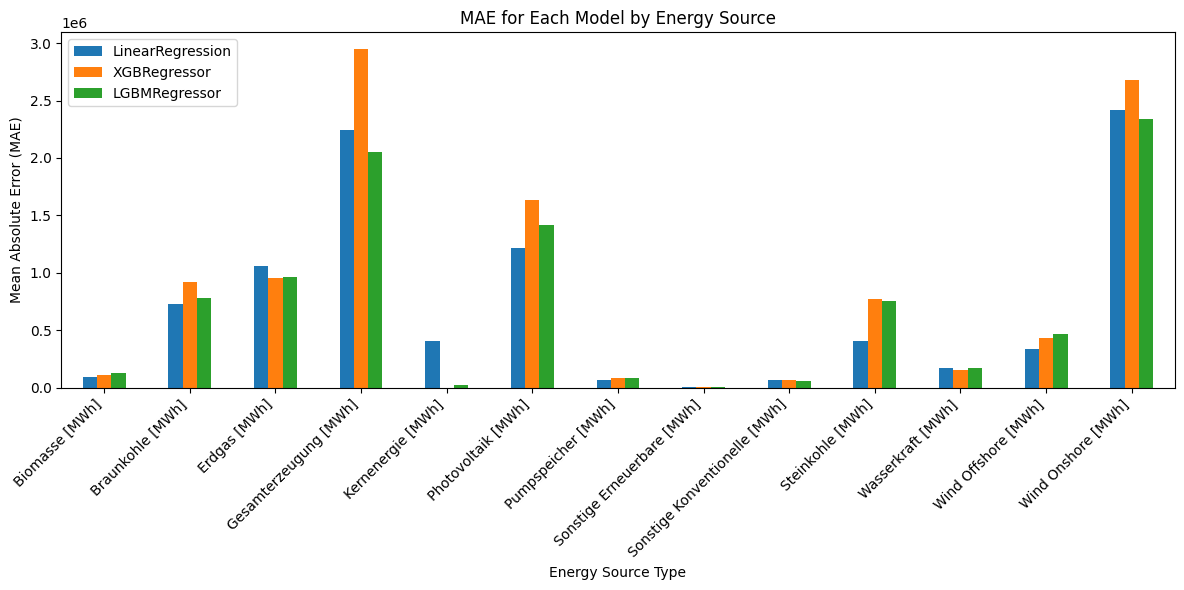

In [28]:
mlf_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###NeuralForecast

In [29]:
models = [
    NHITS(h=3, input_size=12, n_pool_kernel_size=[4,2,1], n_freq_downsample=[12,4,1], scaler_type='robust', max_steps=500),
    TFT(h=3, input_size=12, hidden_size=128, scaler_type='robust', learning_rate=5e-4, max_steps=250)
]

nf = NeuralForecast(models=models, freq='MS', local_scaler_type="standard")

nf.fit(trainErzeugung)


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MAE                      │      0 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    512 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  613 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │  256 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │    129 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 870 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 870 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=250` reached.


In [30]:
predNNErz = nf.predict(h=3)

predNNErz.head()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Output()

,unique_id,ds,NHITS,TFT
0,Biomasse [MWh],2025-08-01,2770909.25,2919550.25
1,Biomasse [MWh],2025-09-01,2736586.00,3022226.75
2,Biomasse [MWh],2025-10-01,3041091.25,3145767.75
3,Braunkohle [MWh],2025-08-01,4665270.00,5531779.50
4,Braunkohle [MWh],2025-09-01,4539418.00,6280674.00


In [31]:
eval_df = pd.merge(testErzeugung, predNNErz, how="left", on=["ds", "unique_id"])
evaluation = evaluate(eval_df, metrics=[mae])
evaluation.head()

,unique_id,metric,NHITS,TFT
0,Biomasse [MWh],mae,6.002812e+04,1.387727e+05
1,Braunkohle [MWh],mae,4.597554e+05,1.177946e+06
2,Erdgas [MWh],mae,1.240962e+06,4.722841e+05
3,Gesamterzeugung [MWh],mae,2.377647e+06,2.205948e+06
4,Kernenergie [MWh],mae,1.250000e-01,3.750000e-01


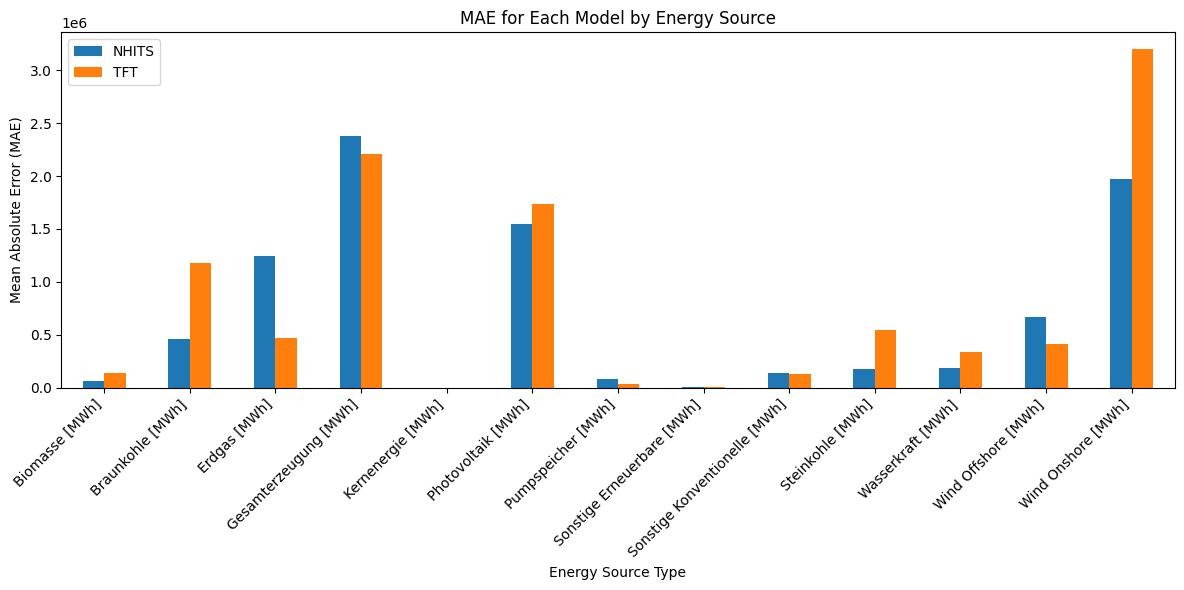

In [32]:
evaluation_to_plot = evaluation.drop(columns="metric").set_index("unique_id")

evaluation_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NN Cross-Validation

In [33]:
models = [
    NHITS(h=3, input_size=12, n_pool_kernel_size=[4,2,1], n_freq_downsample=[12,4,1], scaler_type='robust', max_steps=500),
    TFT(h=3, input_size=12, hidden_size=128, scaler_type='robust', learning_rate=5e-4, max_steps=250)
]

nf = NeuralForecast(models=models, freq='MS', local_scaler_type="standard")

cv_nf = nf.cross_validation(trainErzeugung, n_windows=4, step_size=3)
cv_nf.head()

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.4 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.4 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=250` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Output()

,unique_id,ds,cutoff,NHITS,TFT,y
0,Biomasse [MWh],2024-08-01,2024-07-01,2886836.50,2780949.0,2817887.25
1,Biomasse [MWh],2024-09-01,2024-07-01,2818030.25,2771011.5,2747048.00
2,Biomasse [MWh],2024-10-01,2024-07-01,2978217.75,2774611.0,3041499.25
3,Biomasse [MWh],2024-11-01,2024-10-01,3007136.50,3151056.0,3102041.50
4,Biomasse [MWh],2024-12-01,2024-10-01,3168365.50,3155640.5,3219102.00


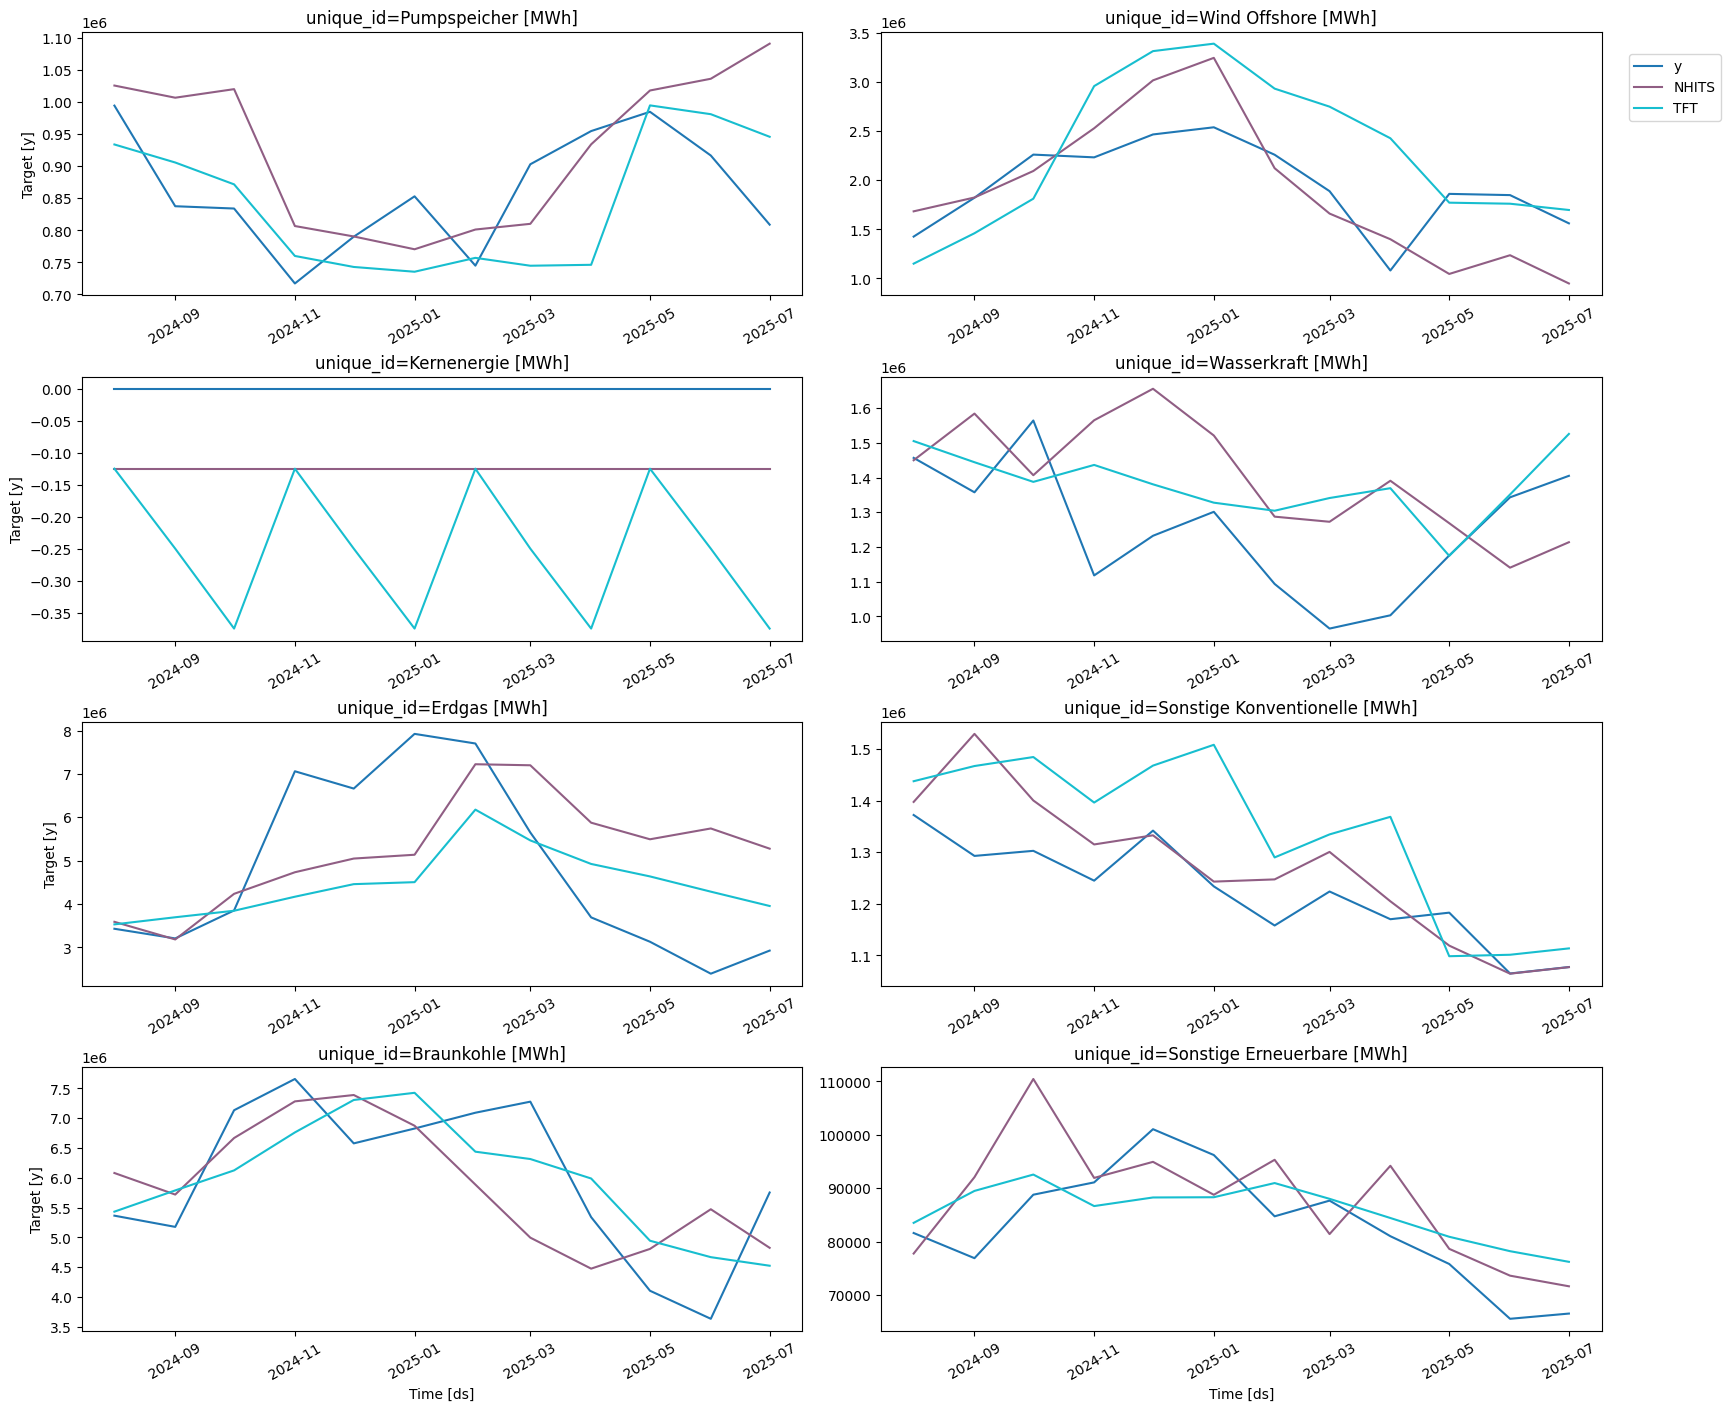

In [34]:
plot_series(forecasts_df=cv_nf.drop(columns='cutoff'))

<Axes: >

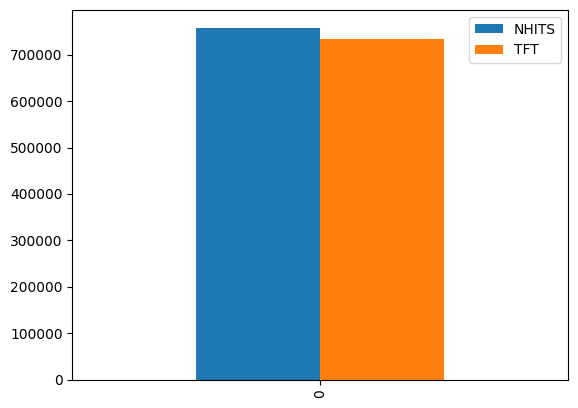

In [35]:
nf_cv_eval = evaluate(cv_nf.drop(columns="cutoff"), metrics=[mae])

nf_cv_eval = nf_cv_eval.drop(columns=["unique_id"]).groupby("metric").mean().reset_index()
nf_cv_eval.plot(kind="bar")

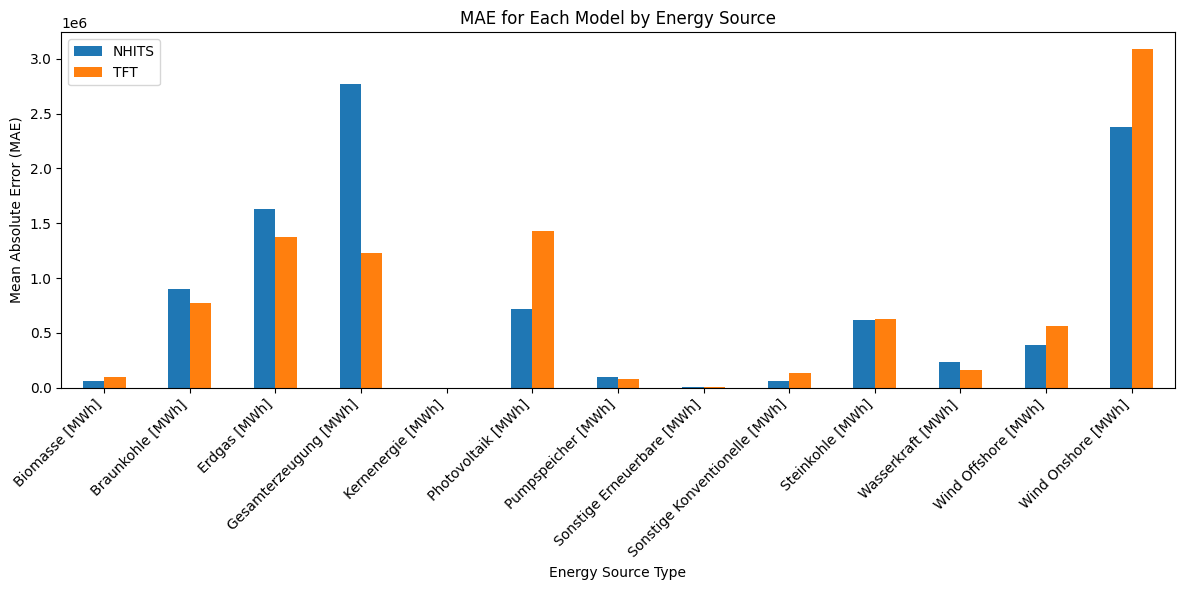

In [36]:
nf_cv_eval = evaluate(cv_nf.drop(columns="cutoff"), metrics=[mae])
nf_to_plot = nf_cv_eval.drop(columns="metric").set_index("unique_id")

nf_to_plot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Combined Plots

MAE

In [37]:
nf_cv_eval_tc = nf_cv_eval.drop(columns="metric")
mlf_cv_eval_tc = mlf_cv_eval.drop(columns="metric")
cv_eval_tc = evaluate(cv.drop(columns="cutoff"), metrics=[mae]).drop(columns="metric")

In [38]:
combined_cv = pd.merge(cv_eval_tc, mlf_cv_eval_tc)
combined_cv = pd.merge(combined_cv, nf_cv_eval_tc)
combined_cv = combined_cv.set_index("unique_id")
combined_cv

,ARIMA,SARIMA,SeasonalNaive,LinearRegression,XGBRegressor,LGBMRegressor,NHITS,TFT
unique_id,,,,,,,,
Biomasse [MWh],1.798670e+05,7.594660e+04,7.352328e+04,9.473322e+04,1.128948e+05,1.290605e+05,6.313178e+04,9.978565e+04
Braunkohle [MWh],8.400439e+05,8.404012e+05,6.713572e+05,7.320591e+05,9.168682e+05,7.846433e+05,8.979347e+05,7.730945e+05
Erdgas [MWh],1.268279e+06,1.206914e+06,8.678421e+05,1.060239e+06,9.559514e+05,9.661771e+05,1.630828e+06,1.373207e+06
Gesamterzeugung [MWh],3.336070e+06,1.946977e+06,1.781049e+06,2.244289e+06,2.946184e+06,2.054985e+06,2.767234e+06,1.233036e+06
Kernenergie [MWh],2.471324e+05,3.848147e+04,0.000000e+00,4.036534e+05,1.417330e+03,2.776630e+04,1.250000e-01,2.500000e-01
Photovoltaik [MWh],1.268663e+06,6.817526e+05,1.032641e+06,1.214617e+06,1.636674e+06,1.418371e+06,7.145638e+05,1.427003e+06
Pumpspeicher [MWh],9.991650e+04,9.991650e+04,8.538231e+04,6.603638e+04,8.849560e+04,8.177627e+04,9.705617e+04,8.041068e+04
Sonstige Erneuerbare [MWh],8.749233e+03,5.737305e+03,1.195057e+04,9.348060e+03,7.013354e+03,7.718781e+03,8.427632e+03,6.733454e+03
Sonstige Konventionelle [MWh],6.825475e+04,5.979186e+04,1.457599e+05,6.420223e+04,7.069206e+04,6.099774e+04,5.941768e+04,1.308924e+05


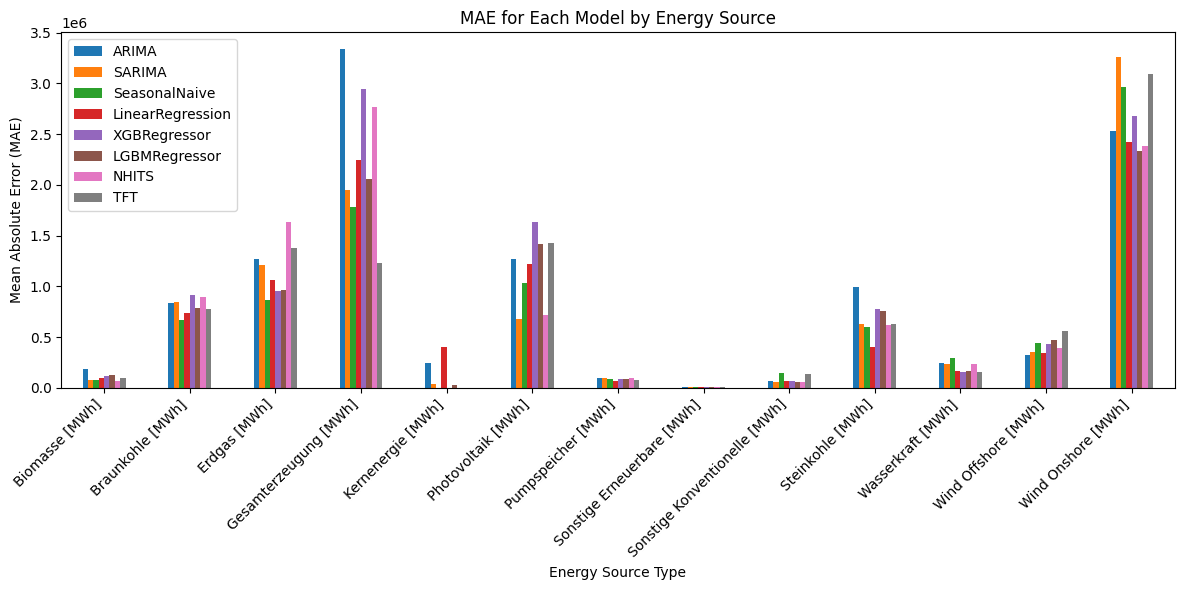

In [39]:
combined_cv.plot(kind="bar", figsize=(12, 6))
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Energy Source Type")
plt.title("MAE for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Combined Predictions

In [40]:
combinedPreds = pd.merge(testErzeugung, predStatErz, "left", ["ds", "unique_id"])
combinedPreds = pd.merge(combinedPreds, predMlErz, "left", ["ds", "unique_id"])
combinedPreds = pd.merge(combinedPreds, predNNErz, "left", ["ds", "unique_id"])
combinedPreds.head()

,ds,unique_id,y,ARIMA,SARIMA,SeasonalNaive,LinearRegression,XGBRegressor,LGBMRegressor,NHITS,TFT
0,2025-08-01,Gesamterzeugung [MWh],31975152.15,3.361645e+07,3.122634e+07,32766383.75,3.454916e+07,3.277776e+07,3.360636e+07,33371410.00,33988460.00
1,2025-09-01,Gesamterzeugung [MWh],34608223.46,3.361645e+07,3.182406e+07,33809086.75,3.610418e+07,3.359743e+07,3.440163e+07,33801248.00,34522596.00
2,2025-10-01,Gesamterzeugung [MWh],39873287.81,3.361645e+07,3.408915e+07,34759714.00,3.794047e+07,3.425710e+07,3.829674e+07,34943580.00,35354380.00
3,2025-08-01,Biomasse [MWh],2852499.35,2.851130e+06,2.781127e+06,2817887.25,2.897712e+06,2.981524e+06,2.991893e+06,2770909.25,2919550.25
4,2025-09-01,Biomasse [MWh],2806358.21,2.866751e+06,2.692517e+06,2747048.00,2.988035e+06,2.941006e+06,3.007209e+06,2736586.00,3022226.75


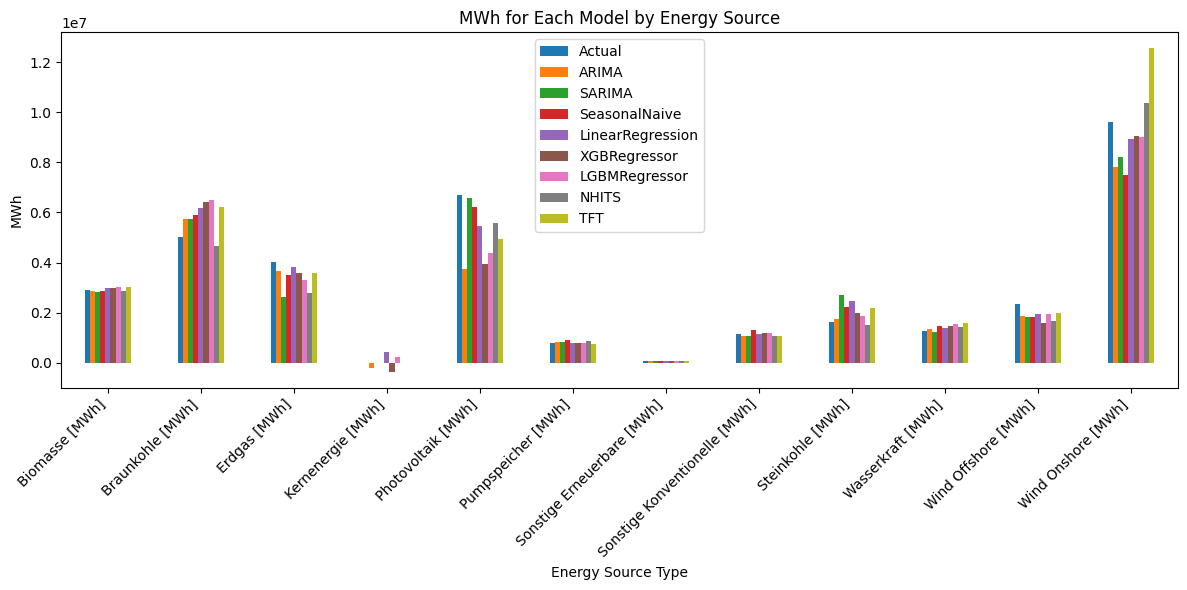

In [41]:
combPredsExGesamt = combinedPreds.loc[combinedPreds["unique_id"] != "Gesamterzeugung [MWh]"]
combPredsExGesamt = combPredsExGesamt.drop(columns="ds")
combPredsExGesamt = combPredsExGesamt.set_index("unique_id")
combPredsExGesamt = combPredsExGesamt.rename(columns={"y": "Actual"})

combPredsExGesamt.groupby(combPredsExGesamt.index).mean().plot(kind="bar", figsize=(12, 6))
plt.ylabel("MWh")
plt.xlabel("Energy Source Type")
plt.title("MWh for Each Model by Energy Source")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

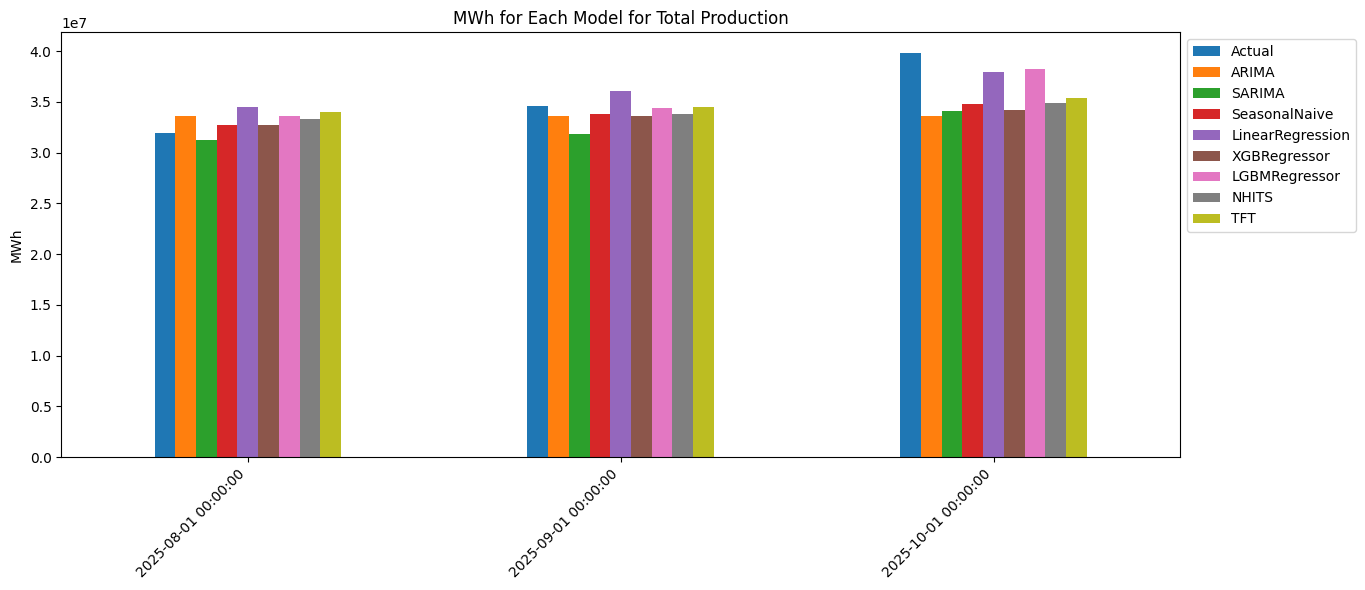

In [42]:
combPredsGesamt = combinedPreds.loc[combinedPreds["unique_id"] == "Gesamterzeugung [MWh]"]
combPredsGesamt = combPredsGesamt.drop(columns="unique_id")
combPredsGesamt = combPredsGesamt.set_index("ds")
combPredsGesamt = combPredsGesamt.rename(columns={"y": "Actual"})

combPredsGesamt.groupby(combPredsGesamt.index).mean().plot(kind="bar", figsize=(12, 6))
plt.ylabel("MWh")
plt.xlabel("")
plt.title("MWh for Each Model for Total Production")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

###Forecast Plot with Best ML Model

In [43]:
statmodels = ["ARIMA", "SARIMA", "SeasonalNaive"]
bestForecastModel = combined_cv.loc["Gesamterzeugung [MWh]"].drop(labels=statmodels, axis=0).idxmin()
bestForecastModel

'TFT'

In [44]:
forecast = combinedPreds.loc[combinedPreds["unique_id"] == "Gesamterzeugung [MWh]", ["ds", bestForecastModel]]
forecast = forecast.set_index("ds")
forecast

,TFT
ds,
2025-08-01,33988460.0
2025-09-01,34522596.0
2025-10-01,35354380.0


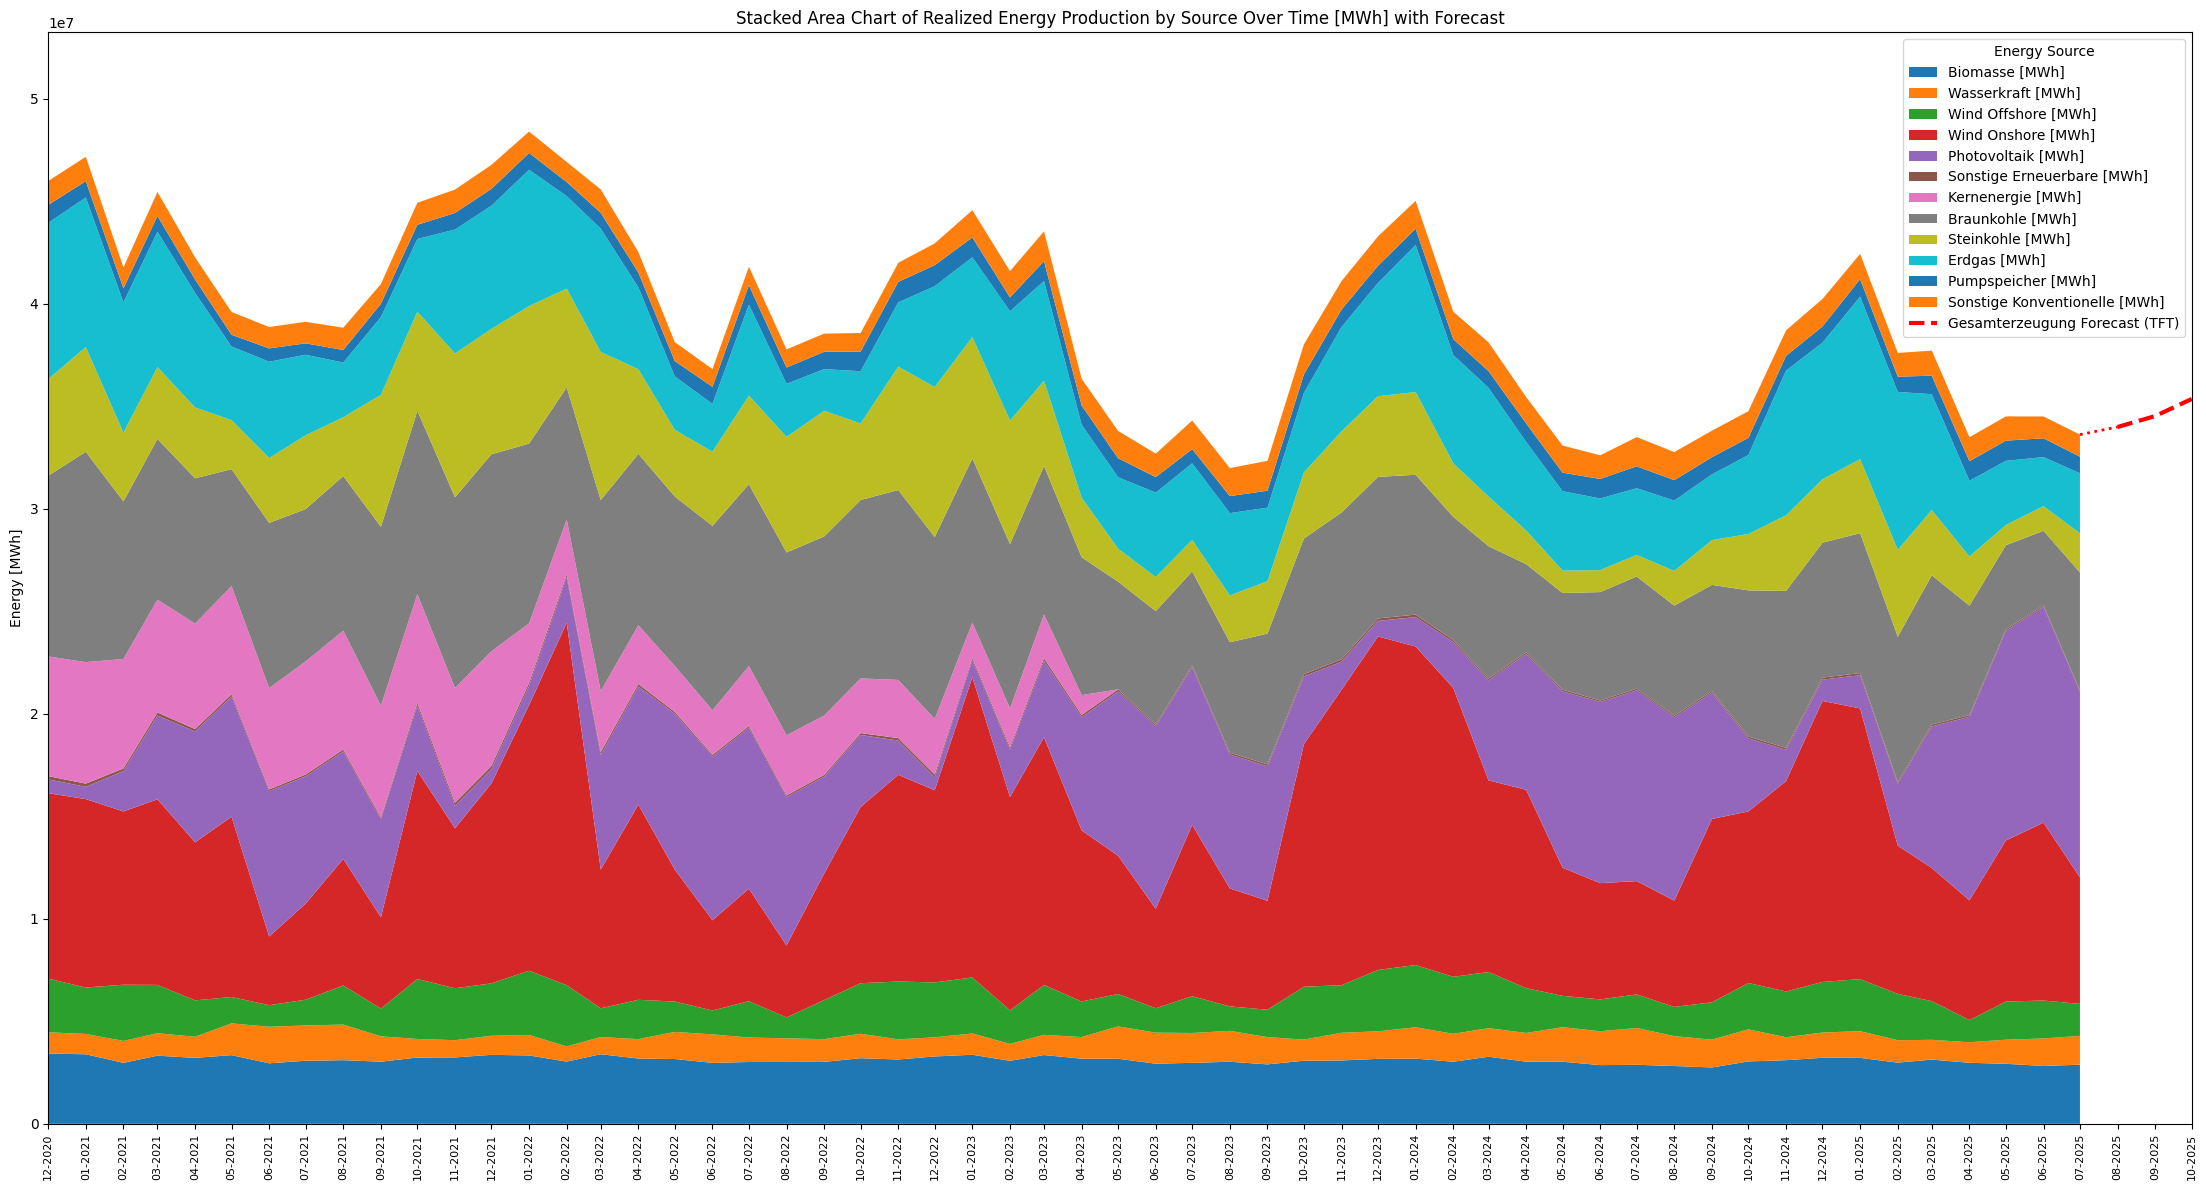

In [45]:
erzeugungPlotDf = erzeugung.iloc[:-3].set_index("Datum von").drop(columns=["Datum bis", "Gesamterzeugung [MWh]"])

productionDates = erzeugungPlotDf.index
forecastDates = forecast.index
allDates = productionDates.append(forecastDates)
allLabels = allDates.strftime("%m-%Y")

fig, ax = plt.subplots(figsize=(25, 12))

ax.stackplot(erzeugungPlotDf.index, erzeugungPlotDf.values.T, labels=erzeugungPlotDf.columns)
ax.plot(forecast.index, forecast[bestForecastModel], color='red', linestyle="--", linewidth=3, label=f'Gesamterzeugung Forecast ({bestForecastModel})')

last_historical_total = erzeugungPlotDf.sum(axis=1).iloc[-1]
first_forecast_value = forecast[bestForecastModel].iloc[0]

bridge_x = [productionDates.max(), forecastDates.min()]
bridge_y = [last_historical_total, first_forecast_value]
ax.plot(bridge_x, bridge_y, color='red', linestyle=':', linewidth=2)

max_historical_sum = erzeugungPlotDf.sum(axis=1).max()
max_forecast_value = forecast[f'{bestForecastModel}'].max()
max_y_value = max(max_historical_sum, max_forecast_value)
ax.set_ylim(bottom=0, top=max_y_value * 1.1)

ax.set_xlim(allDates.min(), allDates.max())
ax.set_xticks(allDates)
ax.set_xticklabels(allLabels, rotation=90, ha='center', fontsize=8)

ax.set_title('Stacked Area Chart of Realized Energy Production by Source Over Time [MWh] with Forecast')
ax.set_ylabel('Energy [MWh]')
ax.set_xlabel('')
ax.legend(title='Energy Source', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()